In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
#import itertools as itr
import numpy as np
import math
#from sklearn.metrics import mean_squared_error
#from random import randrange
#from tabulate import tabulate

import torch
from torch import Tensor, nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
#from torch.func import functional_call, vmap, vjp, jvp, grad

#from scipy.linalg import svdvals, norm
#from scipy.special import softmax
#from scipy.optimize import minimize_scalar

from common.const import DATASET_PATH
from common.util import *
from common.ffn_model.minst.ffn_minst_util import MetaData
from common.optimise import OptimiserEtaSoftmaxArmihoNorm2Base, OptimiserEtaSoftmaxArmihoNorm1Base, reduce_to_active

from torchvision.datasets import CIFAR100
from torchvision import transforms

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_cifar100_epochsd.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
#                datefmt="%m/%d/%Y %I:%M:%S")


#### CIFAR100 dataset

In [3]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR100(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR100(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 128 #32 #64 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32 #*3 USING 0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue for gray-transform
OUTPUT_DIM = 100 #26  # num of classes

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##### UTILS

#### Compare optimisers

In [6]:
def init_weights_copy(net, params):
    net.init_linear_zeros(net.conv1, True)
    net.init_linear_zeros(net.conv2, True)
    net.init_linear_zeros(net.conv3, True)
    net.init_linear_zeros(net.conv4, True)
    net.init_linear_zeros(net.linear5, True)
    net.init_linear_zeros(net.linear6, True)
    with torch.no_grad():
        net.conv1.weight += torch.from_numpy(params['0.weight']).to(DEVICE)
        net.conv1.bias += torch.from_numpy(params['0.bias']).to(DEVICE)
        net.conv2.weight += torch.from_numpy(params['2.weight']).to(DEVICE)
        net.conv2.bias += torch.from_numpy(params['2.bias']).to(DEVICE)
        net.conv3.weight += torch.from_numpy(params['6.weight']).to(DEVICE)
        net.conv3.bias += torch.from_numpy(params['6.bias']).to(DEVICE)
        net.conv4.weight += torch.from_numpy(params['8.weight']).to(DEVICE)
        net.conv4.bias += torch.from_numpy(params['8.bias']).to(DEVICE)
        net.linear5.weight += torch.from_numpy(params['13.weight']).to(DEVICE)
        net.linear5.bias += torch.from_numpy(params['13.bias']).to(DEVICE)
        net.linear6.weight += torch.from_numpy(params['16.weight']).to(DEVICE)
        net.linear6.bias += torch.from_numpy(params['16.bias']).to(DEVICE)

def print_comparison(HISTORY_NORM1, HISTORY_NORM2, HISTORY_OPTFIX):
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    axes[0].plot(HISTORY_NORM1['test_loss'], color='g', alpha=.5, label='Test norm1')
    axes[0].plot(HISTORY_NORM2['test_loss'], color='b', alpha=.5, label='Test norm2')
    #axes[0].plot(HISTORY_ZHS['test_loss'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['test_loss'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['test_loss'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    axes[1].plot(HISTORY_NORM1['test_accuracy'], color='g', alpha=.5, label='Test norm1')
    axes[1].plot(HISTORY_NORM2['test_accuracy'], color='b', alpha=.5, label='Test norm2')
    #axes[1].plot(HISTORY_ZHS['test_accuracy'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['test_accuracy'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['test_accuracy'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same FFN-structure for different optimisers")

    plt.show()

#### Reference CNN

In [7]:
def make_model():
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(4096, 512),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5),
        nn.Linear(512, 100)        
    )

    return model

#### Adapted CNN with the same layers

In [8]:
class CIFAR10ReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.slope_positive = None
        self.slope_negative = None
        self.do_dropout = False

        self.kernel_size_=(3, 3)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=self.kernel_size_, padding='same')
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=self.kernel_size_, padding='same')
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=self.kernel_size_, padding='same')
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=self.kernel_size_, padding='same')
        self.linear5 = nn.Linear(4096, 512)
        self.linear6 = nn.Linear(512, 100)

    def set_slopes(self, slope_positive = 1.0, slope_negative = 0.25):
        self.slope_positive = slope_positive
        self.slope_negative = slope_negative

    def PReLU(self, input: Tensor) -> Tensor:
        input = torch.where(input >= 0, self.slope_positive * input, self.slope_negative * input)
        return input

    def forward_(self, x):
        return self.forward(x)
    
    def forward(self, x):
        #channels*size*size
        #3*32*32->16*32*32 <padding='same'?>
        h1 = self.PReLU(self.conv1(x))
        #16*32*32->32*32*32->32*16*16 <padding='same'?>
        h2 = F.max_pool2d(self.PReLU(self.conv2(h1)), 2)
        if self.do_dropout:
            h2 = F.dropout(h2, 0.25)
        #32*16*16->32*16*16 <padding='same'?>
        h3 = self.PReLU(self.conv3(h2))
        #32*16*16->64*16*16->64*8*8 <padding='same'?>
        h4 = F.max_pool2d(self.PReLU(self.conv4(h3)), 2)
        if self.do_dropout:
            h4 = F.dropout(h4, 0.25)
        #64*8*8->4096->256
        h4flat = torch.flatten(h4, 1)
        h5 = self.PReLU(self.linear5(h4flat))
        if self.do_dropout:
            h5 = F.dropout(h5, 0.5)
        return self.linear6(h5)
    
    def init_weights(self, cb=0.0, cw=1.0):
        logging.debug("CNN weights initialisation with cb={}, cw={}".format(cb, cw))

        #Weight initialisation as in 2.19, 2.20
        self.cb, self.cw = cb, cw
        kernel_size = self.kernel_size_[0]*self.kernel_size_[1]
        self.init_linear_weights(self.conv1, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv2, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv3, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv4, True, cb, cw/kernel_size)
        self.init_linear_weights(self.linear5, True, cb, cw/self.linear5.in_features)
        self.init_linear_weights(self.linear6, True, cb, cw/self.linear6.in_features)

    @staticmethod
    def init_linear_weights(linear, bias_on, var_b=0.0, var_w=1.0):
        nn.init.normal_(linear.weight, mean = 0., std = math.sqrt(var_w)) #approach via torch
        if bias_on:
            nn.init.normal_(linear.bias, mean = 0., std = math.sqrt(var_b))

    @staticmethod
    def init_linear_zeros(linear, bias_on):
        nn.init.zeros_(linear.weight)
        if bias_on:
            nn.init.zeros_(linear.bias)

In [9]:
HISTORY_NORM1 = collections.defaultdict(list)
HISTORY_NORM2 = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)

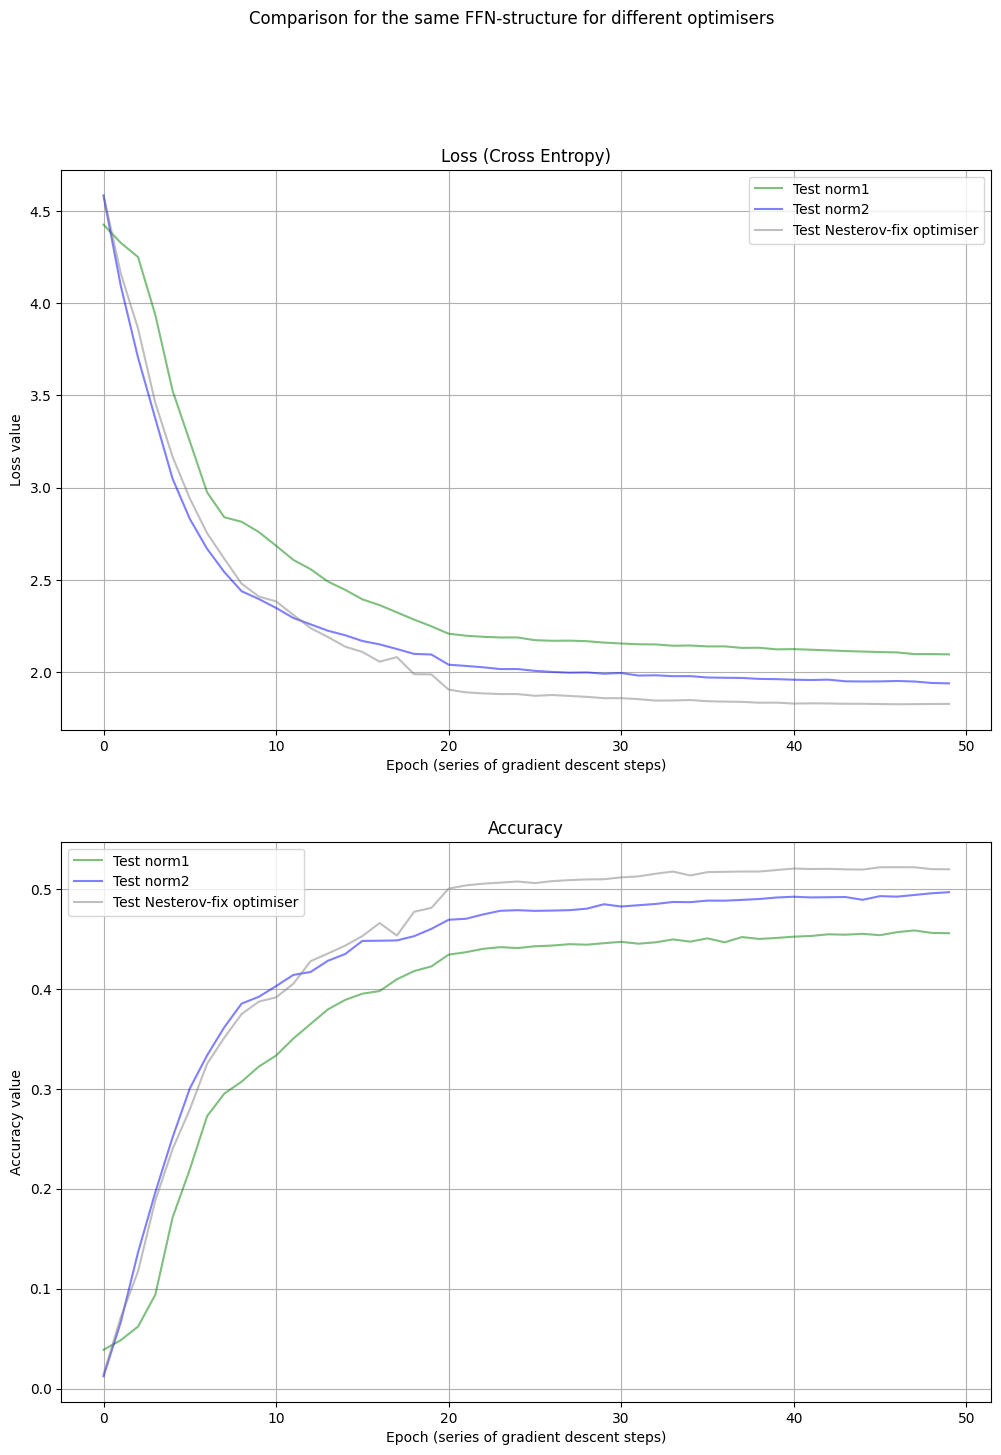

accuracy:
norm1=[0.03886471518987342, 0.04845727848101266, 0.06210443037974683, 0.09394778481012658, 0.17108386075949367, 0.21934335443037975, 0.2725474683544304, 0.29519382911392406, 0.307060917721519, 0.32219145569620256, 0.33316851265822783, 0.3502768987341772, 0.364814082278481, 0.37935126582278483, 0.3888449367088608, 0.3950751582278481, 0.39774525316455694, 0.4095134493670886, 0.4177215189873418, 0.42236946202531644, 0.4341376582278481, 0.4366099683544304, 0.4399723101265823, 0.4416534810126582, 0.4407634493670886, 0.44254351265822783, 0.4432357594936709, 0.44462025316455694, 0.4441257911392405, 0.4456091772151899, 0.44699367088607594, 0.44511471518987344, 0.4464992088607595, 0.44936708860759494, 0.44719145569620256, 0.45045490506329117, 0.4464992088607595, 0.45174050632911394, 0.4498615506329114, 0.4508504746835443, 0.4521360759493671, 0.4528283227848101, 0.45450949367088606, 0.4541139240506329, 0.45500395569620256, 0.45361946202531644, 0.4566851265822785, 0.45836629746835444, 0

In [10]:
def test_loop(testNet, test_loss_meter, test_accuracy_meter):
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = testNet.forward(images)

            zz_logits = np.transpose(logits.detach().cpu().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

NUM_EPOCH = 50
meta = MetaData(output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE)

eta_fixed = 0.01

testOptfix = make_model().to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss()
optimizerFix = optim.SGD(testOptfix.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)
params = {k: v.detach().cpu().numpy().copy() for k, v in testOptfix.named_parameters()}

stepCalcSoftmax2 = OptimiserEtaSoftmaxArmihoNorm2Base(meta, DEVICE)
testNorm2S = CIFAR10ReLU()
testNorm2S.set_slopes(slope_plus, slope_minus)
testNorm2S.do_dropout = False
testNorm2S.to(DEVICE)
init_weights_copy(testNorm2S, params)

stepCalcSoftmax1 = OptimiserEtaSoftmaxArmihoNorm1Base(meta, DEVICE)
testNorm1S = CIFAR10ReLU()
testNorm1S.set_slopes(slope_plus, slope_minus)
testNorm1S.do_dropout = False
testNorm1S.to(DEVICE)
init_weights_copy(testNorm1S, params)

#qu = collections.deque(10*[1.0], 10)
use_ones=False
for epoch in range(NUM_EPOCH):
    do_dropout = not(epoch < 8)
    use_fix = False #do_dropout
    use_ones= (epoch < 1) #not(epoch < 1) # #

    eta_min = 0.01 if epoch < 1 else 0.00001 #if not do_dropout else 0.01 if epoch < 20 else 0.001
    eta_max = 1.0 if epoch < 1 else 0.05 if epoch < 20 else 0.005
    c1 = 0.001 #if epoch < 1 else 0.01 if epoch < 5 else 0.0125 if epoch < 15 else 0.015
    c2 = 0.999 if epoch < 1 else 0.75 if not do_dropout else 0.925 if epoch < 20 else 0.9999

    stepCalcSoftmax1.eta_min = eta_min
    stepCalcSoftmax1.eta_max = eta_max
    stepCalcSoftmax1.stepProcessor.c1 = c1
    stepCalcSoftmax1.stepProcessor.c2 = c2
    testNorm1S.do_dropout = do_dropout

    stepCalcSoftmax2.eta_min = eta_min
    stepCalcSoftmax2.eta_max = eta_max
    stepCalcSoftmax2.stepProcessor.c1 = c1
    stepCalcSoftmax2.stepProcessor.c2 = c2
    testNorm2S.do_dropout = do_dropout
    '''
    c1 = 0.001 if epoch < 1 else 0.01 if epoch < 5 else 0.0125 if epoch < 15 else 0.015 #if epoch < 20 else 0.0175
    c2 = 0.999 if epoch < 1 else 0.75 if epoch < 5 else 0.925  if epoch < 15 else 0.9999
    stepCalcSoftmax2.stepProcessor.c1 = 0.001 if epoch < 1 else 0.01 if epoch < 5 else 0.0125 if epoch < 20 else 0.015
    stepCalcSoftmax2.stepProcessor.c2 = 0.999 if epoch < 1 else 0.75 if epoch < 5 else 0.925   if epoch < 20 else 0.9999
    stepCalcSoftmax2.stepProcessor.c1 = 0.001 if epoch < 1 else 0.01 if epoch < 5 else 0.0125 if epoch < 20 else 0.015
    stepCalcSoftmax2.stepProcessor.c2 = 0.999 if epoch < 1 else 0.75 if epoch < 5 else 0.925  if epoch < 20 else 0.9999    
    "    stepCalcSoftmax2.stepProcessor.c1 = 0.001 if epoch < 1 else 0.01 if epoch < 5 else 0.0125\n",
    "    stepCalcSoftmax2.stepProcessor.c2 = 0.999 if epoch < 1 else 0.75 if epoch < 5 else 0.95\n",    
    '''
         #0.80 if epoch <= 15 else 0.85 if epoch <= 25 else 0.90
    #stepCalcSoftmax2.c1 = 0.001 if epoch < 10 else 0.01 if epoch < 15 else 0.013
        #eta_fixed * math.exp(-0.075*epoch) if epoch < 20 else eta_fixed * 0.1 * math.exp(-0.075*(epoch-20))
     #!-0.075 -0.085 ?0.185 !?-0.175 !-0.15 !-0.115
    #if epoch < 20 else eta_fixed * 0.1 * math.exp(-0.1*(epoch-20))
    optimizerFix.param_groups[0]['lr'] = \
        eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01
    '''
    if len(HISTORY_NORM2['test_loss'])> 2 and do_dropout == False \
        and HISTORY_NORM2['test_loss'][-1] >= HISTORY_NORM2['test_loss'][-2]:
        logging.info("##For norm2-optim-simple do_dropout switched to True")
        do_dropout == True
    '''
    testOptfix.train()
    iter=0
    train_eta2_meter, train_armiho2_meter, train_wolf2_meter = AverageMeter(), AverageMeter(), AverageMeter()
    train_eta1_meter, train_armiho1_meter, train_wolf1_meter = AverageMeter(), AverageMeter(), AverageMeter()

    for train_batch in train_dataloader:
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        pp = labels_to_softhot(labels, meta.output_dim)
        iter+=1

        logging.info("##Step with norm2-optim-simple")
        logging.info("##\n --==Epoch={}, iter={}; momentum={}, Nesterov={}, eta_min={}==--"\
                     .format(epoch, iter, 0.9, True, stepCalcSoftmax2.eta_min))
        with torch.no_grad():
            logits = testNorm2S.forward_(images)
            logits_detached = logits.detach().cpu().numpy()
            qq = softmax(np.transpose(logits_detached), axis=(0)) + 1e-8
            qq_active = reduce_to_active(qq, pp)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), np.average(qq_active)))
        step_result = stepCalcSoftmax2\
            .step(testNorm2S, labels, images, momentum=0.9, Nesterov=True, use_ones=use_ones, use_fix=use_fix)
        train_eta2_meter.update(step_result.eta_value)
        train_armiho2_meter.update(step_result.ck_armiho)
        train_wolf2_meter.update(step_result.ck_wolf)

        logging.info("##Step with norm1-optim-simple")
        logging.info("##\n --==Epoch={}, iter={}; momentum={}, Nesterov={}, eta_min={}==--"\
                     .format(epoch, iter, 0.9, True, stepCalcSoftmax1.eta_min))
        with torch.no_grad():
            logits1 = testNorm1S.forward_(images)
            logits1_detached = logits1.detach().cpu().numpy()
            qq1 = softmax(np.transpose(logits1_detached), axis=(0)) + 1e-8
            qq1_active = reduce_to_active(qq1, pp)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq1_active), np.max(qq1_active), np.average(qq1_active)))
        step1_result = stepCalcSoftmax1\
            .step(testNorm1S, labels, images, momentum=0.9, Nesterov=True, use_ones=use_ones, use_fix=use_fix)
        train_eta1_meter.update(step1_result.eta_value)
        train_armiho1_meter.update(step1_result.ck_armiho)
        train_wolf1_meter.update(step1_result.ck_wolf)        

        logging.info("##Step with Optim-fix, eta={}".format(optimizerFix.param_groups[0]['lr']))
        logitsOptfix = testOptfix.forward(images)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

    HISTORY_NORM1['train_eta'].append(train_eta1_meter.avg)
    HISTORY_NORM1['train_armiho'].append(train_armiho1_meter.avg)
    HISTORY_NORM1['train_wolf'].append(train_wolf1_meter.avg)

    HISTORY_NORM2['train_eta'].append(train_eta2_meter.avg)
    HISTORY_NORM2['train_armiho'].append(train_armiho2_meter.avg)
    HISTORY_NORM2['train_wolf'].append(train_wolf2_meter.avg)

    testNorm1S.do_dropout = False
    testNorm2S.do_dropout = False
    testOptfix.eval()
    # testing loop
    test_loss1S_meter, test_accuracy1S_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm1S, test_loss1S_meter, test_accuracy1S_meter)
    HISTORY_NORM1['test_loss'].append(test_loss1S_meter.avg)
    HISTORY_NORM1['test_accuracy'].append(test_accuracy1S_meter.avg)

    test_loss2S_meter, test_accuracy2S_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm2S, test_loss2S_meter, test_accuracy2S_meter)
    HISTORY_NORM2['test_loss'].append(test_loss2S_meter.avg)
    HISTORY_NORM2['test_accuracy'].append(test_accuracy2S_meter.avg) 

    test_lossOptfix_meter, test_accuracyOptfix_meter = AverageMeter(), AverageMeter(),
    test_loop(testOptfix, test_lossOptfix_meter, test_accuracyOptfix_meter)
    HISTORY_OPTFIX['test_loss'].append(test_lossOptfix_meter.avg)
    HISTORY_OPTFIX['test_accuracy'].append(test_accuracyOptfix_meter.avg)
    
    print_comparison(HISTORY_NORM1, HISTORY_NORM2, HISTORY_OPTFIX)
    print("accuracy:\nnorm1={},\nnorm2={}, \naccuracy Nesterov-fix={}"\
          .format(HISTORY_NORM1['test_accuracy'], HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))


In [11]:
HISTORY_NORM2['train_armiho']

[0.00755089383292866,
 0.006930610095960058,
 0.006654345340568615,
 0.006680214345470559,
 0.006715199692359825,
 0.006760940944332424,
 0.006779820963378535,
 0.006834056049983373,
 0.007450793057346299,
 0.007449936245963732,
 0.007462149584002434,
 0.0074524269326690035,
 0.007454733563116876,
 0.00745313104962081,
 0.007456829211795528,
 0.00745431537152539,
 0.007462205738024745,
 0.007456469779436621,
 0.00745199109763039,
 0.0074581617528968296,
 0.0077527216091223365,
 0.0077477678421289786,
 0.00775215797575609,
 0.007754008536670952,
 0.007750591756235645,
 0.007753580420681189,
 0.007755598346497294,
 0.007754055835707383,
 0.007753458087222853,
 0.007753359193795879,
 0.007752864472654691,
 0.007752809904402264,
 0.007754032195728019,
 0.007753758220388297,
 0.007751421143046525,
 0.007755377025789877,
 0.007755002702912359,
 0.007755218843910386,
 0.0077544869450425795,
 0.007750237591149733,
 0.007756584131592209,
 0.007754196662673693,
 0.007755885964615582,
 0.00775385

In [12]:
HISTORY_NORM2['train_wolf']

[0.9354945242529247,
 0.7674267972870261,
 0.6967577089123632,
 0.6927921101180049,
 0.6842762177330733,
 0.6835765284330464,
 0.6737196835530106,
 0.6685453502584718,
 0.8948764903306639,
 0.8948728055121856,
 0.8938540022294517,
 0.894659013948249,
 0.8945780204250088,
 0.8957942287844375,
 0.8944773013052045,
 0.8944068523764838,
 0.8955578802031766,
 0.894561631252406,
 0.8940779527435982,
 0.8936173255096476,
 0.9809559323739891,
 0.9797646787114449,
 0.9807203516138898,
 0.981023589664521,
 0.9802395971945326,
 0.9809684051940242,
 0.981363847723947,
 0.9810662695629563,
 0.9808070565275008,
 0.9808242755419387,
 0.9807095285117078,
 0.9805874993125241,
 0.9809825369937841,
 0.9808327160750709,
 0.9802616881573046,
 0.9812808161795282,
 0.98113782140427,
 0.9811497862790558,
 0.9810119229194265,
 0.980013945158235,
 0.9815350762608063,
 0.9809002746619538,
 0.9813457482036484,
 0.9808054894276618,
 0.9802647816832157,
 0.9802260028125372,
 0.9805376026653041,
 0.9811681103434537,

In [13]:
HISTORY_NORM2['train_eta']

[0.851848223551971,
 0.03852987301517186,
 0.024437685195551038,
 0.016764169978138833,
 0.017380142741195412,
 0.017607440952939247,
 0.020091086564219575,
 0.020703804215718064,
 0.008940264486390027,
 0.00789892849702716,
 0.007774862220427659,
 0.007128650043165488,
 0.006773442326660642,
 0.006533011759683312,
 0.006351002054682283,
 0.00621931746062394,
 0.006042474091857583,
 0.00587469433690127,
 0.005861822413856017,
 0.005817572366304992,
 0.001003603189380101,
 0.0010121331126963997,
 0.0009631339791523255,
 0.0009251104910235615,
 0.0009248565587512275,
 0.000895078462155386,
 0.0008570611368493216,
 0.000888661694631686,
 0.0008411110681082146,
 0.000845764203627369,
 0.0008489335226514996,
 0.0008082147850596766,
 0.0008292369015362626,
 0.0007981187158935824,
 0.0008085862346008709,
 0.0008105740495819694,
 0.0007980352446687171,
 0.0007837186793907375,
 0.0007878009897503264,
 0.0007946610597182317,
 0.0007797102951174382,
 0.000769011809010665,
 0.0007603210436378541,


In [14]:
print("accuracy norm2={}, \naccuracy Nesterov-fix={}"\
        .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))

accuracy norm2=[0.012361550632911392, 0.06655458860759493, 0.13637262658227847, 0.1964003164556962, 0.2512856012658228, 0.30033623417721517, 0.33336629746835444, 0.3615506329113924, 0.385185917721519, 0.39200949367088606, 0.4026898734177215, 0.41386471518987344, 0.41683148734177217, 0.42800632911392406, 0.43473101265822783, 0.44788370253164556, 0.44808148734177217, 0.448378164556962, 0.45263053797468356, 0.4599485759493671, 0.4690466772151899, 0.4700356012658228, 0.4743868670886076, 0.4780458860759494, 0.4786392405063291, 0.47794699367088606, 0.47824367088607594, 0.4786392405063291, 0.4801226265822785, 0.48457278481012656, 0.4822982594936709, 0.48358386075949367, 0.48486946202531644, 0.4868473101265823, 0.4866495253164557, 0.48823180379746833, 0.48813291139240506, 0.4889240506329114, 0.489814082278481, 0.4912974683544304, 0.4920886075949367, 0.49139636075949367, 0.4915941455696203, 0.49179193037974683, 0.48902294303797467, 0.49268196202531644, 0.4921875, 0.49386867088607594, 0.49554984

In [15]:
#HISTORY_NORM2['train_eta']
base = []
for epoch in range(10):
    base.append(eta_fixed) #* math.exp(-0.075*epoch) if epoch < 20 else eta_fixed * 0.1 * math.exp(-0.075*(epoch-20)))
np.asarray(HISTORY_NORM2['train_eta'])/np.asarray(base[0:38])
        

ValueError: operands could not be broadcast together with shapes (50,) (10,) 

In [ ]:
HISTORY_NORM2['train_eta']

[0.015285067952993671,
 0.009277434863285618,
 0.008607079764250725,
 0.007985162187593722,
 0.007408182206817246,
 0.006872892787909793,
 0.006376281516217808,
 0.005915553643668198,
 0.00548811636094018,
 0.005091564206075456,
 0.004723665527410213,
 0.0043823499246494636,
 0.0040656965974060506,
 0.003771923535631524,
 0.0034993774911115305,
 0.0032465246735835394,
 0.00301216009820852,
 0.0027955801143204006,
 0.0025924599922398815,
 0.0024068696398472445,
 0.0013281892892098963,
 0.0012763028431239866,
 0.0012426129780865067,
 0.001187543631967256,
 0.0011694843494133055,
 0.001134341639877675,
 0.0011460235636987642,
 0.0011489829926686775,
 0.0011306902926686018,
 0.0010899206054821582,
 0.0010913725570778124,
 0.001122022868289991,
 0.0010863638790658383,
 0.0010566156514538257,
 0.001061710730254017,
 0.0010463743320390693,
 0.0010467699578634553,
 0.0010209148612334567,
 0.0010296132952730063,
 0.0010336661643026068,
 0.001050916115744024,
 0.001003426687012818,
 0.0010037535

In [ ]:
HISTORY_NORM2['train_eta']

[0.013527505134022249,
 0.009277434863285711,
 0.0086070797642504,
 0.007985162187594035,
 0.007408182206817095,
 0.0068728927879095755,
 0.006376281516217819,
 0.005915886047137713,
 0.005488863030226298,
 0.0050946015422383036,
 0.004733813318898004,
 0.004392553897358442,
 0.004084760229643128,
 0.003802145267919253,
 0.003557414481612458,
 0.003318384061673349,
 0.0030934619129792712,
 0.002910433806084253,
 0.002754594847485997,
 0.002633615220305129,
 0.0021073081397136053,
 0.002067767349029129,
 0.0019929295644926432,
 0.0020184606533114164,
 0.001983161712651638,
 0.0019687265302203725,
 0.0019240437906109659,
 0.0019659193079068324,
 0.0019383042901715164,
 0.0018669031405471469,
 0.0018762375125915126,
 0.0018800636451614134,
 0.0018896789973937979,
 0.00182804641656338,
 0.0018075817823008733,
 0.0017754402462104022,
 0.001785486739718736,
 0.0018074980987763563,
 0.001767527230945539,
 0.0017606376820712944,
 0.0017279195696054928,
 0.0017417798058429906,
 0.00174980697270